## Transformer Image Classification

This was initially the product of working through [this Datacamp tutorial](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch); we then modified it to train on the [MNIST digits dataset](https://www.kaggle.com/datasets/hojjatk/mnist-dataset).

In [15]:
!pip install torch torchvision torchaudio kagglehub

In [16]:
import kagglehub

path = kagglehub.dataset_download("hojjatk/mnist-dataset")

Using Colab cache for faster access to the 'mnist-dataset' dataset.


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import Dataset, DataLoader
import math
import copy
import numpy as np
import struct
from array import array
from os.path  import join

In [18]:
#https://www.kaggle.com/code/hojjatk/read-mnist-dataset


#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img

        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)


In [19]:
input_path = path
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

Done getting the data.

### Transformer code

First is the self-attention mechanism, generating query, key, and value matrices and producing modified values in the data.

In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        # Ensure that the model dimension (d_model) is divisible by the number of heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Initialize dimensions
        self.d_model = d_model # Model's dimension
        self.num_heads = num_heads # Number of attention heads
        self.d_k = d_model // num_heads # Dimension of each head's key, query, and value

        # Linear layers for transforming inputs
        self.W_q = nn.Linear(d_model, d_model) # Query transformation
        self.W_k = nn.Linear(d_model, d_model) # Key transformation
        self.W_v = nn.Linear(d_model, d_model) # Value transformation
        self.W_o = nn.Linear(d_model, d_model) # Output transformation

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calculate attention scores
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask if provided (useful for preventing attention to certain parts like padding)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        # Softmax is applied to obtain attention probabilities
        attn_probs = torch.softmax(attn_scores, dim=-1)

        # Multiply by values to obtain the final output
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        # Reshape the input to have num_heads for multi-head attention
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # Combine the multiple heads back to original shape
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # Apply linear transformations and split heads
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        # Perform scaled dot-product attention
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

        # Combine heads and apply output transformation
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [21]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

### Positional Encoding

Here we add position to the input terms using `sin` and `cos` values.

In [22]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

### Encoder Layer

Each encoder layer combines the pieces above and adds normalization and a dropout.

In [23]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

### Transformer

The `Transformer` model puts it all together, allowing us to define the number of layers.

In [24]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        # The target mask should allow attention to the current and previous tokens.
        # Since the target sequence length is 1, we just need a mask of ones.
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(2)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool().to(tgt.device)
        tgt_mask = tgt_mask & nopeak_mask

        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        output = self.fc(enc_output)
        return output

### Setting hyperparameters

In [25]:
src_vocab_size = 256
tgt_vocab_size = 10
d_model = 64
num_heads = 4
num_layers = 4
d_ff = 32
max_seq_length = 784 # Max sequence length for MNIST images (28*28)
dropout = 0.1

transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

### Training

*It took me an embarassing amount of time to realize I should be batching the data to prevent overuse of memory.*

In [26]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.long).view(-1, 28*28)
        self.labels = torch.tensor(labels, dtype=torch.long).unsqueeze(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Create Dataset and DataLoader
train_dataset = MNISTDataset(x_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True) # You can adjust the batch_size

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

# Check if CUDA is available and move model and criterion to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
transformer.to(device)
criterion.to(device)


print("Starting training...")
transformer.train()

for epoch in range(5):
    for batch_src, batch_tgt in train_dataloader:
        # Move batch data to GPU
        batch_src = batch_src.to(device)
        batch_tgt = batch_tgt.to(device)

        optimizer.zero_grad()
        # The output shape is (batch_size, sequence_length, vocab_size).
        # We are predicting a single target token, so we take the output for the first target position (index 0).
        output = transformer(batch_src, batch_tgt)

        # Reshape output to (batch_size * sequence_length, vocab_size) and target to (batch_size * sequence_length)
        # Since our target sequence length is 1, this simplifies to (batch_size, vocab_size) and (batch_size,)
        loss = criterion(output[:, 0, :], batch_tgt.squeeze(1))

        loss.backward()
        optimizer.step()
    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

/tmp/ipython-input-4118000301.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.images = torch.tensor(images, dtype=torch.long).view(-1, 28*28)


Using device: cuda
Starting training...
Epoch: 1, Loss: 1.2735235691070557
Epoch: 2, Loss: 1.0196229219436646
Epoch: 3, Loss: 1.0906392335891724
Epoch: 4, Loss: 0.6533940434455872
Epoch: 5, Loss: 0.544371485710144


In [27]:
# Create DataLoader for validation set
val_dataset = MNISTDataset(x_test, y_test)
val_dataloader = DataLoader(val_dataset, batch_size=100, shuffle=False) # No need to shuffle validation data

## Results

Here we show a random collection of images with the real and predicted numbers.

In the next cell we calculate our accuracy score.

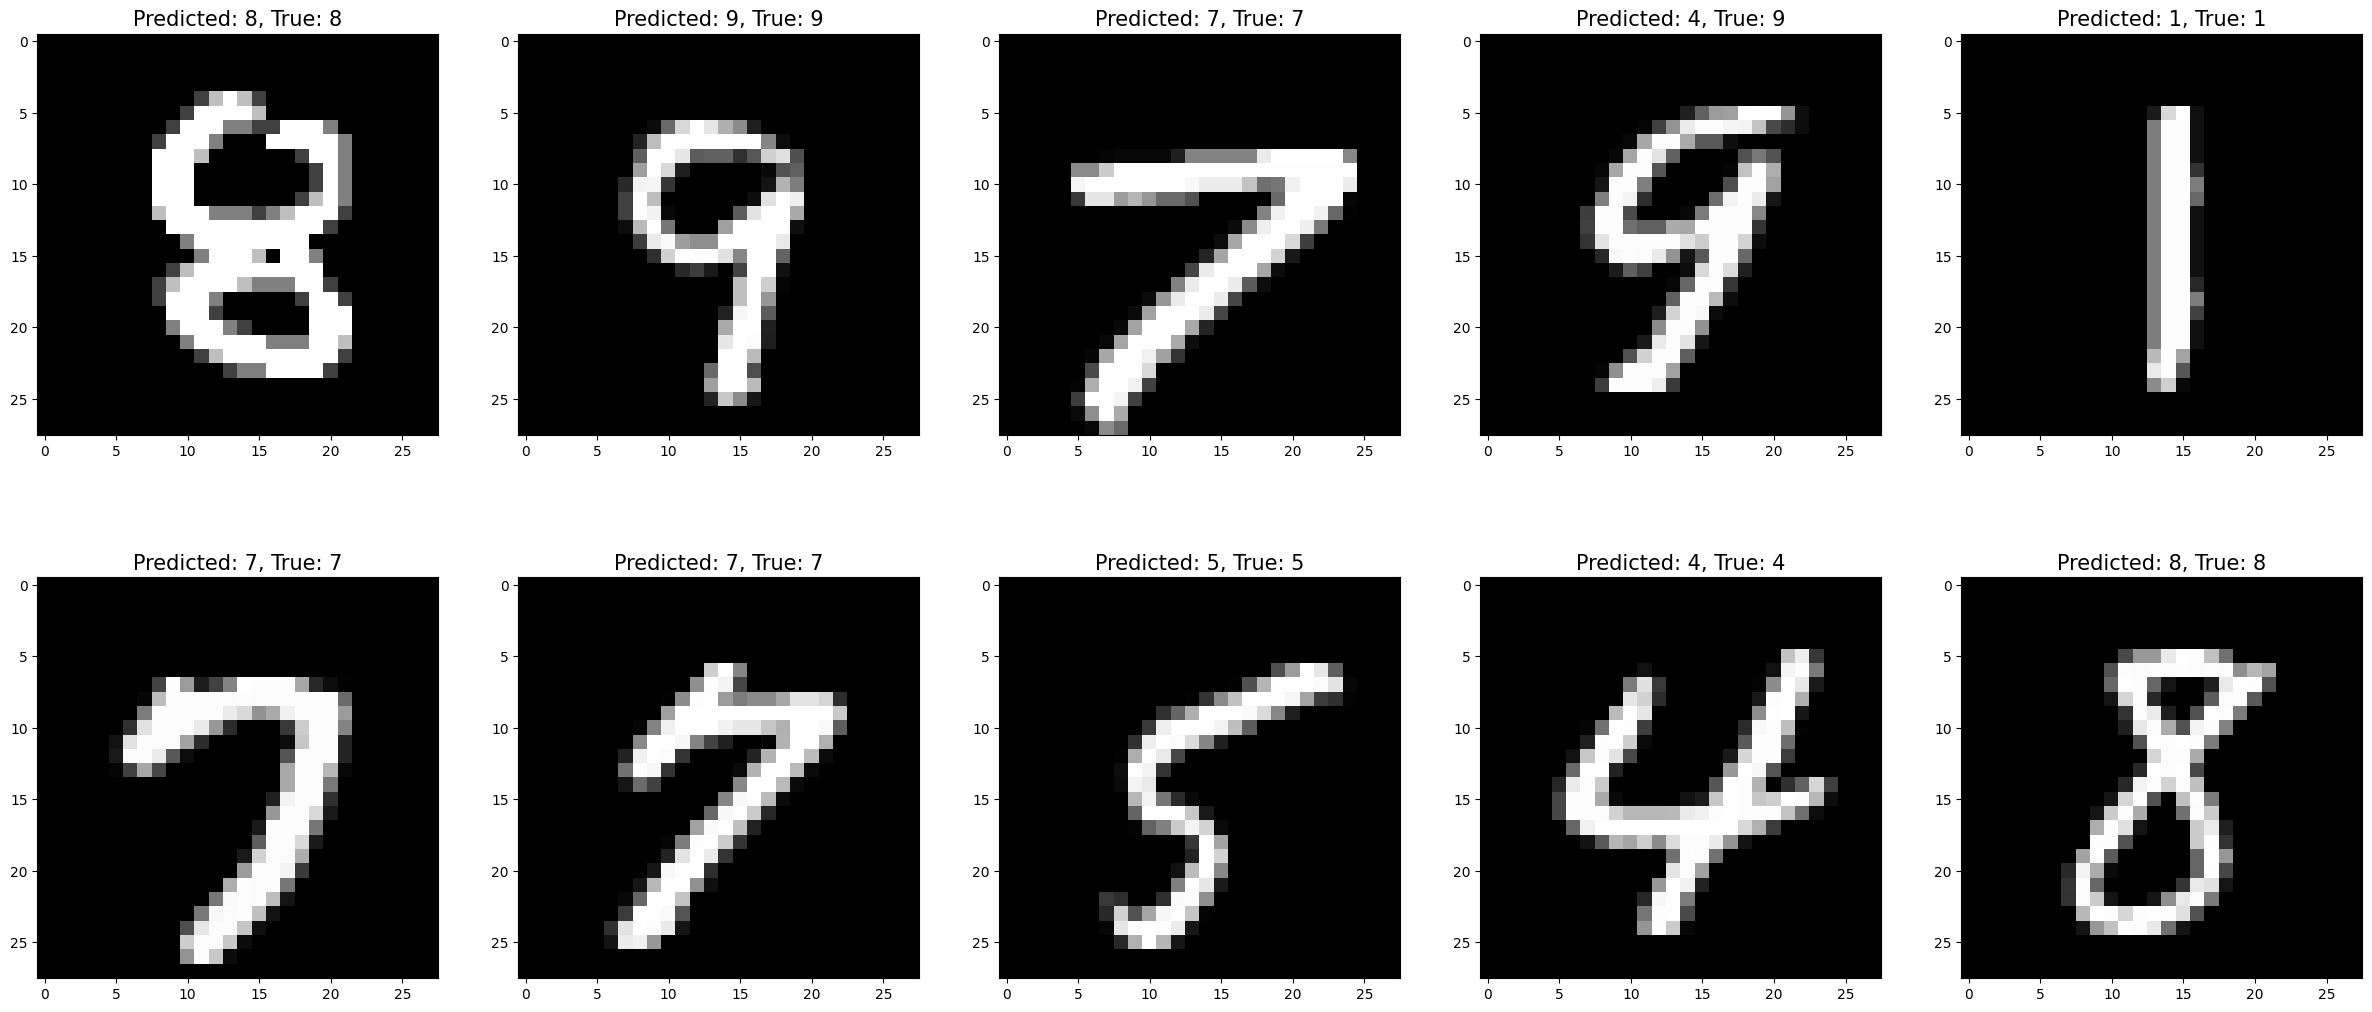

In [28]:
import random
import matplotlib.pyplot as plt

# Helper function to show a list of images with their relating titles
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);
        index += 1

# Get some random test images and their predictions
num_images_to_show = 10
images_to_show = []
titles_to_show = []

# Get predictions for the test set
predicted_labels = []
true_labels = []

transformer.eval()
with torch.no_grad():
    for batch_src, batch_tgt in val_dataloader:
        batch_src = batch_src.to(device)
        batch_tgt = batch_tgt.to(device)

        initial_target = torch.zeros(batch_src.size(0), 1, dtype=torch.long).to(device)
        output = transformer(batch_src, initial_target)
        _, predicted = torch.max(output[:, 0, :], dim=1)

        predicted_labels.extend(predicted.cpu().numpy())
        true_labels.extend(batch_tgt.squeeze(1).cpu().numpy())


# Select some random images to display
random_indices = random.sample(range(len(x_test)), num_images_to_show)

for i in random_indices:
    images_to_show.append(x_test[i])
    titles_to_show.append(f"Predicted: {predicted_labels[i]}, True: {true_labels[i]}")

# Show the images with their predictions and true labels
show_images(images_to_show, titles_to_show)

### Accuracy

Our accuracy could be better.

In [29]:
def calculate_accuracy(model, dataloader, device):
    model.eval() # Set the model to evaluation mode
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch_src, batch_tgt in dataloader:
            # Move batch data to device
            batch_src = batch_src.to(device)
            batch_tgt = batch_tgt.to(device)

            # Get model output
            # We use a dummy target of zeros for prediction as we are predicting a single token
            initial_target = torch.zeros(batch_src.size(0), 1, dtype=torch.long).to(device)
            output = model(batch_src, initial_target)

            # Get predicted class for the single target token
            _, predicted_classes = torch.max(output[:, 0, :], dim=1)

            # Compare with true labels
            correct_predictions += (predicted_classes == batch_tgt.squeeze(1)).sum().item()
            total_predictions += batch_tgt.size(0)

    accuracy = correct_predictions / total_predictions
    return accuracy

# Calculate and print accuracy on the test set
test_accuracy = calculate_accuracy(transformer, val_dataloader, device) # Using val_dataloader for the test set
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7511
